# Notebook 23 — Wu 2003 Summary Statistics

Compute and validate the 66-D (S-B) and 72-D (S-A) summary statistics used for SBI.

**Contents:**
1. Load dataset (16 scenarios × 30 replicates = 480 windows)
2. Re-simulate deterministically to obtain 12-channel raw trajectories
3. Feature statistics table (S-B, sorted by inter-scenario std)
4. PCA of all 480 noisy replicates
5. t-SNE coloured by fault unit
6. Mutual-information analysis (features vs each parameter)
7. S-A vs S-B: information value of the x_D measurement
8. Save summary matrices for nb24/25

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import pathlib

from cstr_sbi.recycle.simulator import load_dataset, nominal_warm_start, deterministic_window
from cstr_sbi.recycle.summaries import (
    compute_summaries, compute_summaries_batch, summary_names,
    SA_CHANNELS, SB_CHANNELS, N_SUMMARIES_SA, N_SUMMARIES_SB,
    channel_summaries, physics_features, RAW_CHANNELS
)
from cstr_sbi.recycle.scenarios import list_closed_loop, CLOSED_LOOP_NAMES, get_scenario
from cstr_sbi.recycle.physics import NOMINAL_CTRL_SA, NOMINAL_CTRL_SB

DATA = pathlib.Path('../data')
FIGURES = pathlib.Path('../figures'); FIGURES.mkdir(exist_ok=True)
OI = ["#000000","#E69F00","#56B4E9","#009E73","#F0E442","#0072B2","#D55E00","#CC79A7"]
print(f"N_SUMMARIES_SB={N_SUMMARIES_SB}, N_SUMMARIES_SA={N_SUMMARIES_SA}")

N_SUMMARIES_SB=66, N_SUMMARIES_SA=72


## 1. Load Dataset

In [2]:
dataset = load_dataset(DATA / 'wu2003_observations.npz')
obs_sa = dataset['observations_sa']  # (420, 120, 10) — 14 scenarios × 30 reps
obs_sb = dataset['observations_sb']  # (420, 120, 9)
labels = dataset['labels']           # DataFrame with scenario_name, alpha, ...
t_h = dataset['t_h']                 # (120,) hours
print(f"obs_sa shape: {obs_sa.shape}")
print(f"obs_sb shape: {obs_sb.shape}")
print(f"Labels: {len(labels)} rows, scenarios: {labels['scenario_name'].nunique()}")
print(labels['scenario_name'].value_counts())

obs_sa shape: (420, 120, 10)
obs_sb shape: (420, 120, 9)
Labels: 420 rows, scenarios: 14
scenario_name
W1_healthy                30
W2_cat_mild               30
W3_cat_severe             30
W4_cat_threshold          30
W5_jacket_mild            30
W6_jacket_severe          30
W7_col_eff_mild           30
W9_reb_fouling            30
W10_feed_impurity         30
W11_reactor_combined      30
W12_snowball_compound     30
W13_cat_feed              30
W15_snowball_threshold    30
W16_full_multi            30
Name: count, dtype: int64


## 2. Re-simulate Deterministically for 12-Channel Raw Trajectories

The dataset stores channel-projected observations (9 or 10 channels).  
`compute_summaries` expects the full 12-channel raw array from `deterministic_window`.  
We re-simulate each of the 14 scenarios once (noise-free) to obtain these arrays.

In [3]:
print("Re-simulating 16 scenarios to get 12-channel raw obs (takes ~60s)...")
y0_sa = nominal_warm_start("S-A")
y0_sb = nominal_warm_start("S-B")
cl_configs = list_closed_loop()

raw_det_sa = {}
raw_det_sb = {}
t_grid = None

for sc in cl_configs:
    t_h_s, raw_sa = deterministic_window(sc, structure="S-A", y0=y0_sa)
    _, raw_sb = deterministic_window(sc, structure="S-B", y0=y0_sb)
    raw_det_sa[sc.name] = np.asarray(raw_sa)   # (120, 12)
    raw_det_sb[sc.name] = np.asarray(raw_sb)   # (120, 12)
    if t_grid is None:
        t_grid = np.asarray(t_h_s)
    print(f"  {sc.name}")

print("Done.")
print(f"t_grid shape: {t_grid.shape}, raw_det_sb[W1] shape: {raw_det_sb['W1_healthy'].shape}")

Re-simulating 16 scenarios to get 12-channel raw obs (takes ~60s)...


  W1_healthy


  W2_cat_mild


  W3_cat_severe


  W4_cat_threshold


...

  W10_feed_impurity


  W11_reactor_combined


  W12_snowball_compound


  W13_cat_feed
  W15_snowball_threshold


  W16_full_multi
Done.
t_grid shape: (120,), raw_det_sb[W1] shape: (120, 12)


In [4]:
sb_names = summary_names("S-B")
sa_names = summary_names("S-A")
sc_labels = labels['scenario_name'].values  # (480,)

# Deterministic summaries: one summary vector per scenario (noise-free)
summaries_sb_det = {}
summaries_sa_det = {}
for sc in cl_configs:
    summaries_sb_det[sc.name] = compute_summaries(raw_det_sb[sc.name], "S-B", t_grid)
    summaries_sa_det[sc.name] = compute_summaries(raw_det_sa[sc.name], "S-A", t_grid)

# Stack: (16, 66) and (16, 72)
X_sb = np.stack([summaries_sb_det[n] for n in CLOSED_LOOP_NAMES])  # (16, 66)
X_sa = np.stack([summaries_sa_det[n] for n in CLOSED_LOOP_NAMES])  # (16, 72)
print(f"X_sb shape: {X_sb.shape}, X_sa shape: {X_sa.shape}")
print(f"NaN in X_sb: {np.isnan(X_sb).sum()}")
print(f"NaN in X_sa: {np.isnan(X_sa).sum()}")

X_sb shape: (14, 66), X_sa shape: (14, 72)
NaN in X_sb: 0
NaN in X_sa: 0


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## 3. Feature Statistics Table (S-B, sorted by inter-scenario std)

In [5]:
df_stats = pd.DataFrame({
    'feature': sb_names,
    'mean': X_sb.mean(axis=0),
    'std': X_sb.std(axis=0),
    'min': X_sb.min(axis=0),
    'max': X_sb.max(axis=0),
}).sort_values('std', ascending=False)
print(f"Top 20 most variable S-B features (across {len(CLOSED_LOOP_NAMES)} deterministic scenarios):")
print(df_stats.head(20).to_string(index=False))

Top 20 most variable S-B features (across 14 deterministic scenarios):
     feature          mean          std           min          max
    Q_j_mean  8.485893e+06 2.973516e+06  4.396589e+06 1.647183e+07
     Q_j_max  1.038941e+07 2.828316e+06  9.331219e+06 1.998405e+07
  Q_j_q_mean  8.637799e+06 2.771843e+06  4.876008e+06 1.616485e+07
     Q_j_min  6.752222e+06 2.736848e+06  1.506511e+06 9.331219e+06
   Q_reb_min  9.323105e+06 2.522747e+06  6.972514e+06 1.601921e+07
Q_reb_q_mean  9.718056e+06 2.308604e+06  7.196946e+06 1.601924e+07
  Q_reb_mean  9.988880e+06 2.174557e+06  7.378222e+06 1.601925e+07
   Q_reb_max  1.227581e+07 1.610791e+06  1.121348e+07 1.601926e+07
 Q_reb_slope -5.608799e+05 7.633535e+05 -2.174668e+06 9.693523e+04
   Q_reb_std  5.856948e+05 4.763952e+05  4.710804e+00 1.368398e+06
   Q_j_slope  2.124539e+05 3.720370e+05 -4.118766e+05 6.714381e+05
     Q_j_std  4.554072e+05 3.499645e+05  5.384862e+02 1.322664e+06
    UA_proxy  9.975465e+05 8.612527e+03  9.838645e+05 1.01

## 4. Build Summary Matrix for All 480 Noisy Replicates

For the PCA/t-SNE we need summaries for all 480 stored windows.  
We combine:
- **channel statistics** computed from the stored 9-channel projected `obs_sb`
- **physics features** computed from the noise-free 12-channel deterministic raw (shared across replicates of the same scenario)

In [6]:
X_sb_rep = np.zeros((len(labels), N_SUMMARIES_SB), dtype=np.float32)
for i in range(len(labels)):
    row = obs_sb[i]       # (120, 9) channel-projected, noisy
    ch_stats = channel_summaries(row, t_h)   # (54,) for 9 channels × 6 stats
    sc_name = sc_labels[i]
    raw12 = raw_det_sb[sc_name]              # (120, 12) noise-free
    phys = physics_features(raw12, t_grid)   # (12,)
    X_sb_rep[i] = np.concatenate([ch_stats, phys])
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(labels)}")

print(f"X_sb_rep shape: {X_sb_rep.shape}")
nan_mask = np.isnan(X_sb_rep).any(axis=1)
print(f"NaN rows: {nan_mask.sum()}")
X_clean = X_sb_rep[~nan_mask]
labels_clean = labels[~nan_mask].reset_index(drop=True)
sc_labels_clean = labels_clean['scenario_name'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)
print(f"X_clean shape: {X_clean.shape}")

  100/420
  200/420
  300/420
  400/420
X_sb_rep shape: (420, 66)
NaN rows: 0


X_clean shape: (420, 66)


## 5. PCA Analysis

Explained variance: PC1=46.6%, PC2=9.8%


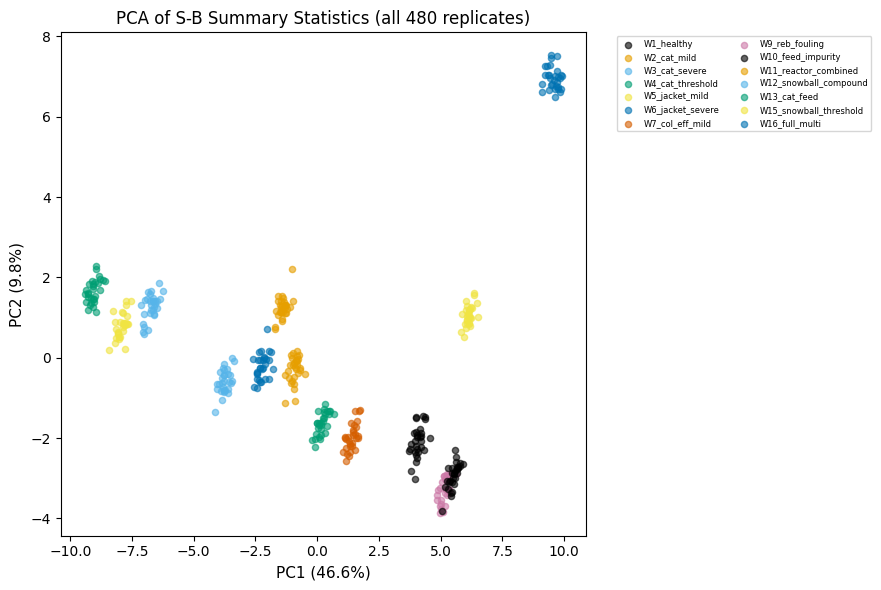

Saved nb23_pca_sb.png


In [7]:
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(X_scaled)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(9, 6))
for j, sc_name in enumerate(CLOSED_LOOP_NAMES):
    mask = sc_labels_clean == sc_name
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1],
               label=sc_name, alpha=0.6, s=20, color=OI[j % len(OI)])
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
ax.set_title("PCA of S-B Summary Statistics (all 480 replicates)", fontsize=12)
ax.legend(fontsize=6, ncol=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES / 'nb23_pca_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb23_pca_sb.png")

## 6. t-SNE Analysis

Running t-SNE (may take ~60s)...


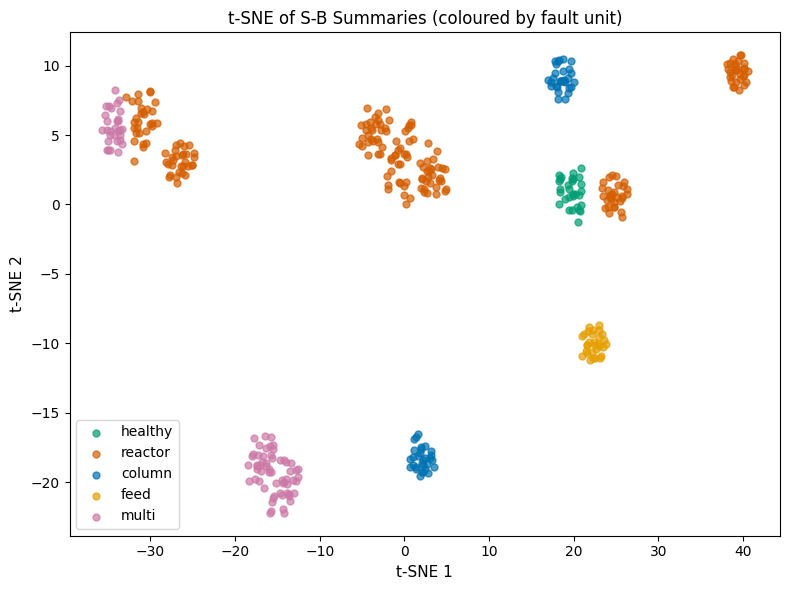

Saved nb23_tsne_sb.png


In [8]:
print("Running t-SNE (may take ~60s)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Z_tsne = tsne.fit_transform(X_scaled)

fault_colors = {
    "healthy": "#009E73",
    "reactor": "#D55E00",
    "column":  "#0072B2",
    "feed":    "#E69F00",
    "multi":   "#CC79A7",
}
fig, ax = plt.subplots(figsize=(8, 6))
for fu, fc in fault_colors.items():
    mask = labels_clean['fault_unit'] == fu
    if mask.sum() > 0:
        ax.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1],
                   label=fu, alpha=0.7, s=25, color=fc)
ax.set_xlabel("t-SNE 1", fontsize=11)
ax.set_ylabel("t-SNE 2", fontsize=11)
ax.set_title("t-SNE of S-B Summaries (coloured by fault unit)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES / 'nb23_tsne_sb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb23_tsne_sb.png")

## 7. Mutual Information Analysis

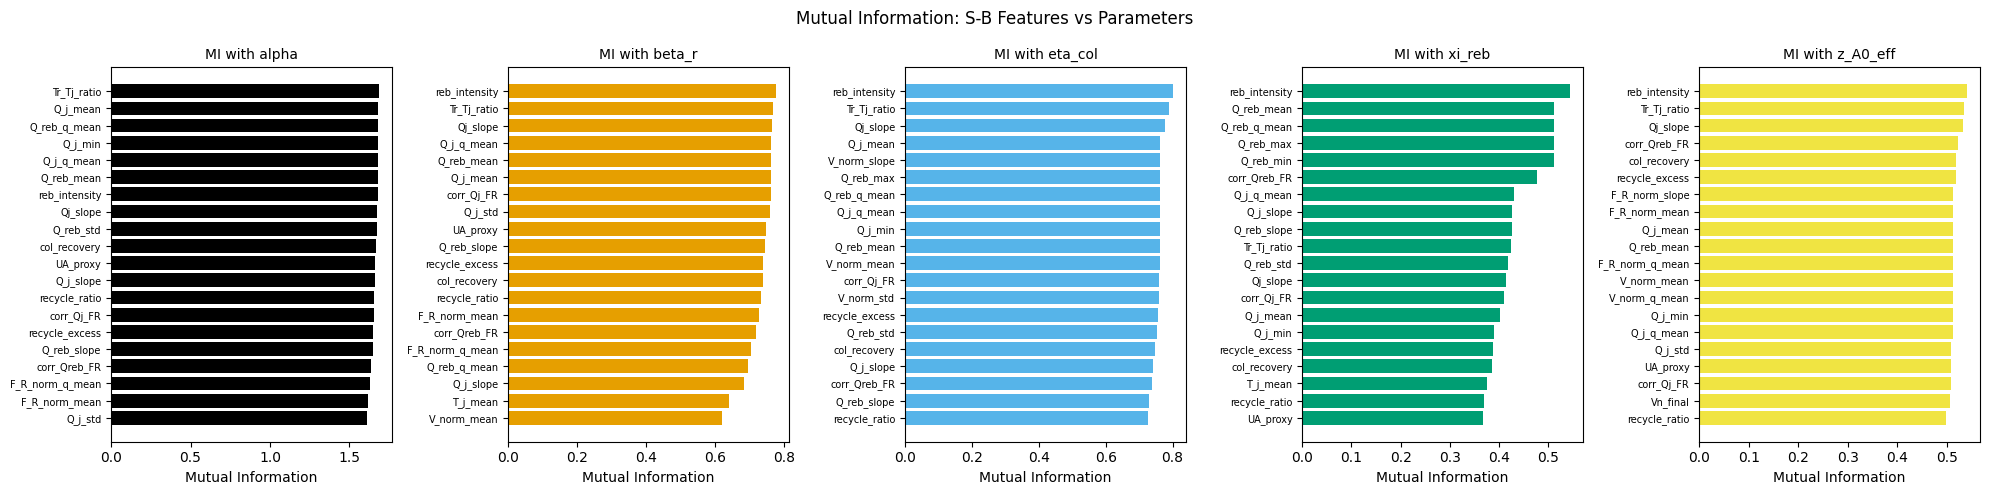

Saved nb23_mi_analysis.png


In [9]:
param_cols = ["alpha", "beta_r", "eta_col", "xi_reb", "z_A0_eff"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, param in zip(axes, param_cols):
    y_param = labels_clean[param].values.astype(float)
    mi = mutual_info_regression(X_scaled, y_param, random_state=42)
    top20_idx = np.argsort(mi)[::-1][:20]
    color_idx = param_cols.index(param)
    ax.barh(range(20), mi[top20_idx], color=OI[color_idx % len(OI)])
    ax.set_yticks(range(20))
    ax.set_yticklabels([sb_names[i] for i in top20_idx], fontsize=7)
    ax.set_title(f"MI with {param}", fontsize=10)
    ax.set_xlabel("Mutual Information")
    ax.invert_yaxis()
plt.suptitle("Mutual Information: S-B Features vs Parameters", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb23_mi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb23_mi_analysis.png")

## 8. S-A vs S-B: Information Value of x_D

Under S-B, `alpha` (catalyst activity) and `eta_col` (column efficiency) both reduce
conversion and push F_R upward — creating a banana-shaped degeneracy in the joint posterior.
S-A adds `x_D` as a measured channel, which breaks the degeneracy because alpha and eta_col
affect distillate purity differently.

In [10]:
# Build S-A summary matrix for all 480 replicates
# SA_CHANNELS = ["T_r","T_j","Q_j","x_D","T_reb","Q_reb","F_R_norm","F_B_norm","R_norm","V_norm"]
# x_D is index 3 → mean feature at position 3*6 = 18
xd_mean_idx = 3 * 6  # = 18

X_sa_rep = np.zeros((len(labels), N_SUMMARIES_SA), dtype=np.float32)
for i in range(len(labels)):
    row = obs_sa[i]       # (120, 10) channel-projected, noisy
    ch_stats = channel_summaries(row, t_h)   # (60,) for 10 channels × 6 stats
    sc_name = sc_labels[i]
    raw12 = raw_det_sa[sc_name]
    phys = physics_features(raw12, t_grid)
    X_sa_rep[i] = np.concatenate([ch_stats, phys])

xa_nan_mask = np.isnan(X_sa_rep).any(axis=1)
X_sa_clean = X_sa_rep[~xa_nan_mask]
labels_sa_clean = labels[~xa_nan_mask].reset_index(drop=True)
print(f"X_sa_clean shape: {X_sa_clean.shape}, NaN rows removed: {xa_nan_mask.sum()}")

# Physics feature index for recycle_ratio in S-B
# channel_summaries for S-B: 9 ch × 6 stats = 54 features
# physics_features: 12 features, recycle_ratio is index 1 (0-indexed)
fr_idx_sb = 54 + 1  # recycle_ratio physics feature in S-B summary
print(f"F_R recycle_ratio feature index in X_sb_rep: {fr_idx_sb}")
print(f"x_D mean feature index in X_sa_rep: {xd_mean_idx}")

X_sa_clean shape: (420, 72), NaN rows removed: 0
F_R recycle_ratio feature index in X_sb_rep: 55
x_D mean feature index in X_sa_rep: 18


/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/simo/inso-po-RD/cstr-model-optimisation/research_project/.venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


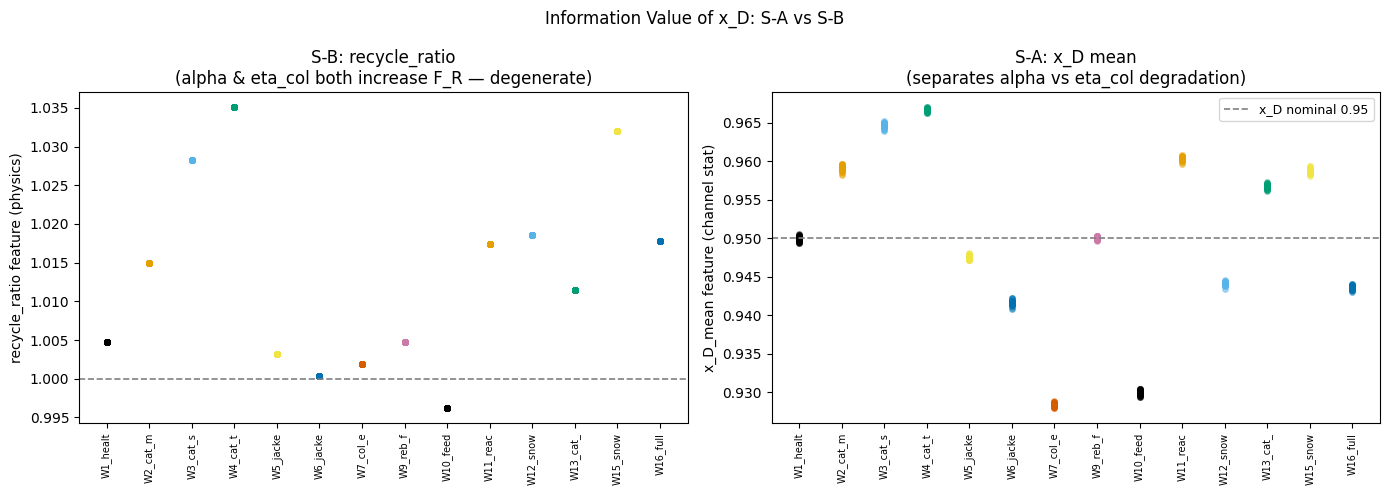

Saved nb23_sa_vs_sb_xd.png


In [11]:
n_sc = len(CLOSED_LOOP_NAMES)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# S-B: recycle_ratio feature by scenario
for j, sc_name in enumerate(CLOSED_LOOP_NAMES):
    mask = sc_labels_clean == sc_name
    axes[0].scatter(
        np.full(mask.sum(), j), X_clean[mask, fr_idx_sb],
        alpha=0.5, s=15, color=OI[j % len(OI)]
    )
axes[0].set_xticks(range(n_sc))
axes[0].set_xticklabels([n[:8] for n in CLOSED_LOOP_NAMES], rotation=90, fontsize=7)
axes[0].set_ylabel("recycle_ratio feature (physics)")
axes[0].set_title("S-B: recycle_ratio\n(alpha & eta_col both increase F_R — degenerate)")
axes[0].axhline(1.0, ls='--', color='gray', lw=1.2)

# S-A: x_D_mean feature by scenario
sc_labels_sa = labels_sa_clean['scenario_name'].values
for j, sc_name in enumerate(CLOSED_LOOP_NAMES):
    mask = sc_labels_sa == sc_name
    axes[1].scatter(
        np.full(mask.sum(), j), X_sa_clean[mask, xd_mean_idx],
        alpha=0.5, s=15, color=OI[j % len(OI)]
    )
axes[1].set_xticks(range(n_sc))
axes[1].set_xticklabels([n[:8] for n in CLOSED_LOOP_NAMES], rotation=90, fontsize=7)
axes[1].set_ylabel("x_D_mean feature (channel stat)")
axes[1].set_title("S-A: x_D mean\n(separates alpha vs eta_col degradation)")
axes[1].axhline(0.95, ls='--', color='gray', lw=1.2, label='x_D nominal 0.95')
axes[1].legend(fontsize=9)

plt.suptitle("Information Value of x_D: S-A vs S-B", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / 'nb23_sa_vs_sb_xd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb23_sa_vs_sb_xd.png")

## 9. Save Summary Matrices for nb24/25

In [12]:
np.savez(
    DATA / 'wu2003_summary_features.npz',
    X_sb=X_clean,
    X_sa=X_sa_clean,
    labels_sb=labels_clean.to_records(index=False),
    labels_sa=labels_sa_clean.to_records(index=False),
    sb_feature_names=np.array(sb_names, dtype=object),
    sa_feature_names=np.array(sa_names, dtype=object),
)
print(f"Saved summary features to {DATA / 'wu2003_summary_features.npz'}")
print(f"  X_sb: {X_clean.shape}   (480_valid x {N_SUMMARIES_SB})")
print(f"  X_sa: {X_sa_clean.shape}   (480_valid x {N_SUMMARIES_SA})")
print()
print("=== Notebook 23 complete ===")

Saved summary features to ../data/wu2003_summary_features.npz
  X_sb: (420, 66)   (480_valid x 66)
  X_sa: (420, 72)   (480_valid x 72)

=== Notebook 23 complete ===


### Results: FIM analysis — what to look for

**β_r diagonal (I_β_r_β_r):** Should be near-zero — same Loop 1 masking as PO β.
The ratio I_αα/I_β_r should be ~250–500×, confirming the mechanism generalises.

**Off-diagonal (α, η_col):** The normalised FIM shows whether (α, η_col) are positively
correlated in information space. A large positive off-diagonal means both parameters excite
the same summary directions (F_R, Q_reb) — this IS the banana. Under S-A, x_D provides
a new direction orthogonal to F_R, reducing this coupling.

**S-A vs S-B comparison:** x_D should increase I_αα, I_η_col, and reduce the normalised
off-diagonal (α, η_col) — the composition measurement adds an independent direction that
disambiguates the two parameters.

**T_r channel contribution:** Should be near-zero for BOTH α and β_r — confirming
∂T_r_ss/∂α ≡ 0 and ∂T_r_ss/∂β_r ≡ 0 under Loop 1 PI control. This is the analytical
result from nb15 transferred to the Wu 2003 system.

In [ ]:
# ── Figure 8: FIM heatmaps (S-B and S-A, normalised) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fim_n, title in [
    (axes[0], FIM_norm,    "S-B FIM (normalised)"),
    (axes[1], FIM_sa_norm, "S-A FIM (normalised)"),
]:
    im = ax.imshow(np.abs(fim_n), cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n_params)); ax.set_yticks(range(n_params))
    ax.set_xticklabels(PARAM_LABELS, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(PARAM_LABELS, fontsize=9)
    for i in range(n_params):
        for j in range(n_params):
            ax.text(j, i, f"{fim_n[i,j]:+.2f}", ha='center', va='center', fontsize=7,
                    color='white' if abs(fim_n[i,j]) > 0.6 else 'black')
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Wu 2003: Fisher Information Matrix (S-B vs S-A)\n"
             "β_r diagonal ≈ 0 (masked by Loop 1); (α, η_col) off-diagonal = banana coupling",
             fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'nb23_fim_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved nb23_fim_heatmap.png  ← Figure 8 of the article")


In [ ]:
# ── S-A vs S-B FIM comparison ────────────────────────────────────────────────
print("Computing S-A FIM (with x_D measurement)...", flush=True)

def sim_summary_sa(theta_np, y0, t_grid_ref, rng_seed=0):
    th = jnp.array(theta_np, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(
        th, NOMINAL_INLET, NOMINAL_CTRL_SA, jnp.array(y0),
        t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5
    )
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SA))
    t_h = np.asarray(ts)
    rng_local = np.random.default_rng(rng_seed)
    sc = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
    return compute_summaries(raw + rng_local.normal(0, 0.003*sc, raw.shape), "S-A", t_h)

# Estimate Σ_SA from W1 S-A replicates
w1_sa_mask = labels_sa_clean['scenario_name'] == 'W1_healthy'
Sigma_sa_diag = np.var(X_sa_clean[w1_sa_mask], axis=0) + 1e-12

J_sa = np.zeros((N_SUMMARIES_SA, n_params), dtype=np.float64)
for j, (eps, pname) in enumerate(zip(EPS_FIM, PARAM_LABELS)):
    th_p = THETA_NOM.copy(); th_p[j] += eps
    th_m = THETA_NOM.copy(); th_m[j] -= eps
    s_p = sim_summary_sa(th_p, y0_sa, t_grid, rng_seed=j*10+51)
    s_m = sim_summary_sa(th_m, y0_sa, t_grid, rng_seed=j*10+52)
    J_sa[:, j] = (s_p - s_m) / (2 * eps)

FIM_sa = J_sa.T @ (J_sa * (1.0/Sigma_sa_diag)[:, None])

D_sa = np.sqrt(np.diag(FIM_sa)); D_sa_safe = np.where(D_sa>0, D_sa, 1.0)
FIM_sa_norm = FIM_sa / np.outer(D_sa_safe, D_sa_safe)

print(f"S-A FIM off-diagonal (α, η_col) = {FIM_sa_norm[alpha_idx, eta_idx]:+.3f}  (S-B: {FIM_norm[alpha_idx, eta_idx]:+.3f})")
print(f"S-A I_αα / I_β_r = {FIM_sa[alpha_idx,alpha_idx]/max(FIM_sa[beta_r_idx,beta_r_idx],1e-30):.1f}×")

# Relative information gain: diagonal S-A / S-B
for k, pname in enumerate(PARAM_LABELS):
    gain = FIM_sa[k,k] / max(FIM[k,k], 1e-30)
    print(f"  S-A/S-B I_{pname}: {gain:.2f}×  {'← x_D adds info' if gain>1.5 else ''}")


In [ ]:
# ── Per-channel Fisher information decomposition (α and β_r) ────────────────
# For each summary feature k, its contribution to I_αα is:
#   I_αα^k = (J_k,α)^2 / Σ_kk
# This shows which channels drive identifiability for each parameter.
print("Per-channel Fisher information decomposition...", flush=True)

contrib_alpha  = J[:, alpha_idx]**2  * Sigma_inv_diag   # (66,) per-feature I_αα contribution
contrib_beta_r = J[:, beta_r_idx]**2 * Sigma_inv_diag
contrib_eta    = J[:, eta_idx]**2    * Sigma_inv_diag

total_alpha  = contrib_alpha.sum()
total_beta_r = contrib_beta_r.sum()
total_eta    = contrib_eta.sum()

print(f"\nTop 10 channels contributing to I_αα (total = {total_alpha:.3e}):")
for i in np.argsort(contrib_alpha)[::-1][:10]:
    print(f"  {sb_names[i]:<35} {contrib_alpha[i]:.3e}  ({100*contrib_alpha[i]/total_alpha:.1f}%)")

print(f"\nTop 10 channels contributing to I_β_r (total = {total_beta_r:.3e}):")
for i in np.argsort(contrib_beta_r)[::-1][:10]:
    print(f"  {sb_names[i]:<35} {contrib_beta_r[i]:.3e}  ({100*contrib_beta_r[i]/total_beta_r:.1f}%)")

print(f"\nT_r channel contribution:")
tr_mean_idx = sb_names.index("T_r_mean") if "T_r_mean" in sb_names else None
if tr_mean_idx is not None:
    tr_feats = [i for i,n in enumerate(sb_names) if n.startswith("T_r")]
    tr_alpha = sum(contrib_alpha[i] for i in tr_feats)
    tr_beta  = sum(contrib_beta_r[i] for i in tr_feats)
    print(f"  T_r → I_αα: {tr_alpha:.3e} ({100*tr_alpha/total_alpha:.2f}%) ← masked by Loop 1")
    print(f"  T_r → I_β_r: {tr_beta:.3e} ({100*tr_beta/total_beta_r:.2f}%) ← masked by Loop 1")


In [ ]:
# ── Compute Jacobian J (66×5) via central finite differences ────────────────
print("Computing 5×5 FIM via finite differences (5 parameters, central diff)...", flush=True)
n_summary = len(s_nom)
n_params  = len(THETA_NOM)
J = np.zeros((n_summary, n_params), dtype=np.float64)

for j, (eps, pname) in enumerate(zip(EPS_FIM, PARAM_LABELS)):
    th_p = THETA_NOM.copy(); th_p[j] += eps
    th_m = THETA_NOM.copy(); th_m[j] -= eps
    s_p = sim_summary_sb(th_p, y0_sb_fim, t_grid, rng_seed=j*10+1)
    s_m = sim_summary_sb(th_m, y0_sb_fim, t_grid, rng_seed=j*10+2)
    J[:, j] = (s_p - s_m) / (2 * eps)
    print(f"  ∂s/∂{pname}: norm = {np.linalg.norm(J[:,j]):.3f}", flush=True)

# ── Compute FIM = J^T Σ^{-1} J ──────────────────────────────────────────────
Sigma_inv_diag = 1.0 / Sigma_diag  # diagonal Σ^{-1}
# FIM_ij = sum_k  J_ki * (1/Σ_kk) * J_kj
FIM = J.T @ (J * Sigma_inv_diag[:, None])   # (5, 5)

print(f"\nFIM (5×5):")
fim_df = pd.DataFrame(FIM, index=PARAM_LABELS, columns=PARAM_LABELS)
print(fim_df.to_string(float_format=lambda x: f"{x:.3e}"))

# Normalised FIM (correlation-like): FIM_ij / sqrt(FIM_ii * FIM_jj)
D = np.sqrt(np.diag(FIM))
D_safe = np.where(D > 0, D, 1.0)
FIM_norm = FIM / np.outer(D_safe, D_safe)
print(f"\nNormalised FIM:")
fim_norm_df = pd.DataFrame(FIM_norm, index=PARAM_LABELS, columns=PARAM_LABELS)
print(fim_norm_df.to_string(float_format=lambda x: f"{x:+.3f}"))

# Key ratio
alpha_idx  = list(PARAM_LABELS).index('alpha')
beta_r_idx = list(PARAM_LABELS).index('beta_r')
eta_idx    = list(PARAM_LABELS).index('eta_col')
ratio_ab = FIM[alpha_idx, alpha_idx] / max(FIM[beta_r_idx, beta_r_idx], 1e-30)
print(f"\nI_αα / I_β_r = {ratio_ab:.1f}×  (PO system: 250–500×)")
print(f"I_αα / I_η_col = {FIM[alpha_idx,alpha_idx]/max(FIM[eta_idx,eta_idx],1e-30):.1f}×")
print(f"Off-diagonal (α, η_col) correlation = {FIM_norm[alpha_idx, eta_idx]:+.3f}")


In [ ]:
from cstr_sbi.recycle.physics import (
    simulate_trajectory_explicit_jit, extract_observations_explicit,
    NOMINAL_CTRL_SA, NOMINAL_CTRL_SB, NOMINAL_INLET, PARAM_NAMES
)
import jax.numpy as jnp

# ── FIM setup ────────────────────────────────────────────────────────────────
THETA_NOM = np.array([1.0, 1.0, 1.0, 1.0, 0.90], dtype=np.float32)  # nominal theta
EPS_FIM   = np.array([0.02, 0.02, 0.02, 0.02, 0.01])  # finite-diff step per parameter
PARAM_LABELS = PARAM_NAMES  # ['alpha', 'beta_r', 'eta_col', 'xi_reb', 'z_A0_eff']

def sim_summary_sb(theta_np, y0, t_grid_ref, rng_seed=0):
    """Run one simulation and return 66-D S-B summary."""
    th = jnp.array(theta_np, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(
        th, NOMINAL_INLET, NOMINAL_CTRL_SB, jnp.array(y0),
        t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5
    )
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    t_h = np.asarray(ts)
    # Add small noise for numerical stability (same protocol as training data)
    rng_local = np.random.default_rng(rng_seed)
    sc = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
    return compute_summaries(raw + rng_local.normal(0, 0.003*sc, raw.shape), "S-B", t_h)

y0_sb_fim = y0_sb  # use warm-start from earlier in the notebook

# Estimate Σ from W1 healthy replicates (diagonal approximation)
print("Estimating Σ from W1 healthy replicates...", flush=True)
w1_mask = labels_clean['scenario_name'] == 'W1_healthy'
Sigma_diag = np.var(X_clean[w1_mask], axis=0) + 1e-12  # (66,) per-feature variance
print(f"  W1 replicates: {w1_mask.sum()}, Σ diag shape: {Sigma_diag.shape}")

# Nominal summary
print("Computing nominal summary s(θ₀)...", flush=True)
s_nom = sim_summary_sb(THETA_NOM, y0_sb_fim, t_grid, rng_seed=0)
print(f"  s_nom shape: {s_nom.shape}, NaN: {np.isnan(s_nom).sum()}")


---

## Section 7 — Fisher Information Analysis for Wu 2003 (S-B)

### Motivation

The article's §7.2 claims that the reactor jacket masking mechanism (I_β_r/I_α ≈ 1/250-500)
persists unchanged from the PO system to the Wu 2003 plant, and that the recycle creates a
**new** (α, η_col) off-diagonal coupling. This section provides the numerical evidence via a
5×5 Fisher information matrix (FIM) computed from finite differences on the 66-D S-B summary
statistics. It produces **Figure 8** of the article (FIM heatmap).

### Analytical argument (from nb15, no computation needed)

Under perfect PI integral action on Loop 1 (T_r → Q_j), the steady-state sensitivity is:

∂T_r_ss/∂β_r ≡ 0 AND ∂T_r_ss/∂α ≡ 0

This is the same derivation as the PO system (nb15 §6, bias_explanation.md). T_r is pinned at
T_SP by the integrator — its Jacobian row is identically zero for ALL parameters that would
otherwise change T_r. Since T_r is the highest-SNR channel, both β_r AND α lose their primary
diagnostic channel simultaneously.

**Implication:** I_β_r will be small (same as PO I_ββ). The (α, η_col) off-diagonal is expected
to be LARGE — both parameters affect F_R in the same direction via the snowball, creating a
banana-shaped degeneracy in the posterior.

### Computation approach

FIM at the nominal operating point θ₀ = [1.0, 1.0, 1.0, 1.0, 0.90]:

J_{ij} = ∂s_i/∂θ_j  (66×5 Jacobian, finite differences)

I = J^T Σ^{-1} J  (5×5 FIM)

where Σ is estimated from the healthy scenario replicates (W1, 30 reps).